# Calculate pointwise escape times for CdV



In [57]:
import matplotlib.pyplot as plt
import numpy as np
import cdv_utils
import importlib
import pickle
import numba as nb
import math
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches

plt.rcParams['text.usetex'] = True
plt.rcParams['pgf.texsystem'] = "pdflatex"
plt.rcParams['text.latex.preamble'] = (
    r'\usepackage{amsmath,amsfonts,amssymb,cmbright,standalone}')
importlib.reload(cdv_utils)

<module 'cdv_utils' from '/home/schoelleh96/Nextcloud/AGPfahl/AGMeeting/20241119_PaperClub/code/code_deposit/cdv_utils.py'>

In [ ]:

from cdv_utils import (
    load_d, make_L3d, compute_clusters_from_TO, solve_escape_from_Q,
    calculate_escape_times, classify_new_trajectory, classify_new_trajectory_radius,
    affinity_entry_sum, find_nearby_indices, plot_loglog_slope_analysis, fit_hmm,
    plot_lifetime_distributions_lines
)
fixed = np.array([
    [0.7285286,   0.15657308, -0.36810966, -0.32854071, -0.08004622, 0.34314342],
    [0.94484848, 0.10714876, -0.00858286, -0.71094887, -0.17206714, 0.03996197]
])

In [59]:
dt_traj = 1
sigma = 0.01
sig_max = 0.03
sig_step = 1e-4
subsample_step = 1
dt_eff = dt_traj * subsample_step
epsilon = 2 * dt_eff * sigma**2
t_fin = int(2e4 * subsample_step)
print(epsilon)

0.0002


## Define the regime

In [60]:
n_eig = 12
n_clusters = 2
n_init = 10
eig_indices = [1, 2, 3, 4]   # zero-based eigenvector indices to use
random_state = 0
det_traj = load_d(
    "./cdv_model/data/dataOro20_sigma0p00000000.bin", 6, int(2e6))[:t_fin:subsample_step, :]


L = make_L3d(det_traj, epsilon)

In [61]:
# --- compute clusters from TO ---
det_cluster_res = compute_clusters_from_TO(L.T,
                                           n_eig=n_eig,
                                           n_clusters=n_clusters,
                                           n_init=n_init,
                                           eig_indices=eig_indices,
                                           random_state=random_state)

labels = det_cluster_res["labels"].copy()

In [ ]:
blocking_idx = 1
blocking_mask = np.nonzero(labels == blocking_idx)[0]
entries = np.where(
    (labels[:-1] != blocking_idx) & (labels[1:] == blocking_idx))[0]+1
indices_in_reduced = np.nonzero(labels == blocking_idx)[0].searchsorted(
    entries[np.isin(entries, np.nonzero(labels == blocking_idx)[0])])

/tmp/ipykernel_19645/2709418404.py:11: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(fixed_pcs[0, 0], fixed_pcs[0, 1], c='black', s=64, alpha=1,
/tmp/ipykernel_19645/2709418404.py:13: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(fixed_pcs[1, 0], fixed_pcs[1, 1], c='red', s=64, alpha=1,


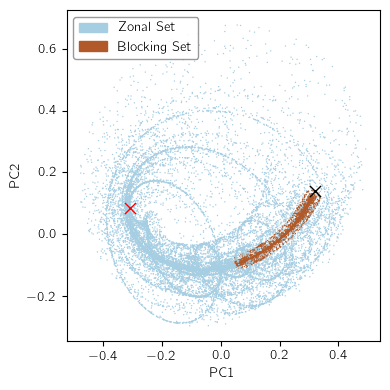

/tmp/ipykernel_19645/2709418404.py:34: UserWarning: Adding colorbar to a different Figure <Figure size 400x400 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(sc, ticks=range(len(np.unique(det_cluster_res["labels"]))))


<Figure size 640x480 with 0 Axes>

In [67]:
plt.figure(figsize=(4, 4))
labels[det_cluster_res["labels"] == 0] = 1
labels[det_cluster_res["labels"] == 1] = 0
cmap = plt.get_cmap("Paired", len(np.unique(labels)))
pca = PCA(n_components=3)
PC_scores = pca.fit_transform(det_traj)
fixed_pcs = pca.transform(fixed)
sc = plt.scatter(PC_scores[:-1, 0], PC_scores[:-1, 1],
                 c=(labels == blocking_idx), s=1, linewidth=0, cmap=cmap, label='Clusters',
                 rasterized=True)
plt.scatter(fixed_pcs[0, 0], fixed_pcs[0, 1], c='black', s=64, alpha=1,
            edgecolors='black', linewidths=1, marker="x")
plt.scatter(fixed_pcs[1, 0], fixed_pcs[1, 1], c='red', s=64, alpha=1,
            edgecolors='black', linewidths=1, marker="x")

handles = [
    mpatches.Patch(color=cmap(0), label=f'Zonal Set'),
    mpatches.Patch(color=cmap(1), label=f'Blocking Set')
]
plt.legend(
    handles=handles,
    loc='upper left',           # position inside the plot
    frameon=True,
    framealpha=0.8,             # slightly transparent background
    facecolor='white',
    edgecolor='gray'
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.savefig(
    f'../../Sets_subsample_{subsample_step}_sigma_{sigma}.pdf', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()
cbar = plt.colorbar(sc, ticks=range(len(np.unique(det_cluster_res["labels"]))))
cbar.set_label('cluster')
cbar.set_ticklabels(range(len(np.unique(det_cluster_res["labels"]))))

In [68]:
print(np.asarray(calculate_escape_times(
    labels, dt=dt_eff)[blocking_idx]).mean())

L = make_L3d(det_traj, 0)
Q = L[labels == blocking_idx][:,
                              labels == blocking_idx].tocsr()

t_escape = solve_escape_from_Q(Q) * dt_eff
print(t_escape[indices_in_reduced].mean())
print("entries:", entries.shape[0])
print("blocking states:", np.where(labels == blocking_idx)[0].shape)

64.71232876712328
[iterative] GMRES converged with ILU preconditioner (n=4724, nnz=4651, density=0.0002084).
64.71232876712328
entries: 73
blocking states: (4724,)


## Compare to HMM

In [37]:
inits = np.r_[fixed, [(fixed[0] + fixed[1]) / 2]]
state_centers, states_sd, states = fit_hmm(
    det_traj, 3, initial_centers=inits)

Transition Matrix:
Shape: (3, 3)
State 1: [0.5859 0.4141 0.0000]
State 2: [0.3453 0.5973 0.0573]
State 3: [0.1149 0.0000 0.8851]



/tmp/ipykernel_23155/2183496106.py:6: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(fixed_pcs[0, 0], fixed_pcs[0, 1], c='black', s=64, alpha=1,
/tmp/ipykernel_23155/2183496106.py:8: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(fixed_pcs[1, 0], fixed_pcs[1, 1], c='red', s=64, alpha=1,


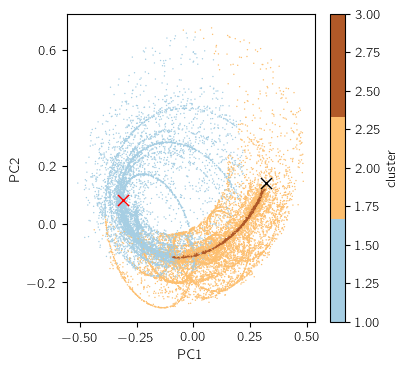

In [38]:
plt.figure(figsize=(4, 4))
cmap = plt.get_cmap("Paired", len(np.unique(states)))
sc = plt.scatter(PC_scores[:, 0], PC_scores[:, 1],
                 c=states, s=1, linewidth=0, cmap=cmap, label='Clusters',
                 rasterized=True)
plt.scatter(fixed_pcs[0, 0], fixed_pcs[0, 1], c='black', s=64, alpha=1,
            edgecolors='black', linewidths=1, marker="x")
plt.scatter(fixed_pcs[1, 0], fixed_pcs[1, 1], c='red', s=64, alpha=1,
            edgecolors='black', linewidths=1, marker="x")

plt.xlabel("PC1")
plt.ylabel("PC2")

cbar = plt.colorbar(sc)
cbar.set_label('cluster')

In [39]:
print("Points in both blocking sets (TO vs. HMM):",
      np.intersect1d(np.where(labels == blocking_idx)[0],
                     np.where(states == 3)[0]).shape[0])
print("Points in TO blocking set:", np.where(
    labels == blocking_idx)[0].shape[0])
print("Points in HMM blocking set:", np.where(states == 3)[0].shape[0])

Points in both blocking sets (TO vs. HMM): 3452
Points in TO blocking set: 4989
Points in HMM blocking set: 4039


# Get loglogplot

In [64]:
sigmas_loglog = np.logspace(-4, 0, 50)
eps_vals = 2.0 * dt_eff * sigmas_loglog**2

# for all points
sums_all = np.array([affinity_entry_sum(det_traj, eps, chunk=1000)
                     for eps in eps_vals]) / det_traj.shape[0]**2

# for blocking set
eps_max = 2.0 * dt_eff * sig_max**2
points = find_nearby_indices(
    det_traj, labels, eps=eps_max, regime=blocking_idx)
sums_block = np.array([affinity_entry_sum(det_traj[points], eps, chunk=1000)
                       for eps in eps_vals]) / det_traj[points].shape[0]**2

In [62]:
def plot_loglog_slope_analysis(sigmas_loglog, sums_all, sums_block):
    from matplotlib.colors import to_rgba
    from matplotlib.lines import Line2D
    logx = np.log10(sigmas_loglog)
    fig, ax = plt.subplots(figsize=(4, 2.5))
    x_line_log = np.linspace(logx[0], logx[-1], 300)
    table_rows = []
    # plot datasets and slope-lines
    for idx, (sums, lab, col, m) in enumerate(zip([sums_all, sums_block],
                                                  ["All", "Blocking"],
                                                  ['tab:blue', 'tab:orange'],
                                                  ['x', '+'])):
        sums = np.asarray(sums)
        logy = np.log10(sums)

        # local slopes between consecutive log points
        slopes = np.diff(logy) / np.diff(logx)
        imax = int(np.argmax(slopes))
        slope_max = slopes[imax]

        # geometric mean location for sigma* (between imax and imax+1)
        sig_at_max = np.sqrt(sigmas_loglog[imax] * sigmas_loglog[imax + 1])

        # anchor: midpoint in log space
        logx_mid = 0.5 * (logx[imax] + logx[imax + 1])
        logy_mid = 0.5 * (logy[imax] + logy[imax + 1])

        # line (in log space) anchored at midpoint
        y_line_log = slope_max * (x_line_log - logx_mid) + logy_mid

        # main curve: log-log
        ax.loglog(sigmas_loglog, sums, '-', color=col, marker=m,
                  markersize=4, linewidth=1,
                  label=lab, markevery=1)
        ax.loglog(10 ** x_line_log, 10 ** y_line_log, '--', color=col,
                  linewidth=1, alpha=1)

        # point of maximum slope: same colour
        y_at_max = 10 ** (slope_max * (logx_mid - logx_mid) +
                          logy_mid)  # == 10**logy_mid
        ax.scatter([sig_at_max], [y_at_max], color=col, edgecolor='k',
                   s=(2*5), zorder=10)

        # accumulate row for the summary table
        table_rows.append((lab, f"{sig_at_max:.3g}", f"{slope_max:.4f}"))
    ax.set_xlim(sigmas_loglog[0], sigmas_loglog[-1])
    ax.set_xlabel(r'Noise Strength $\sigma$')
    ax.set_ylabel(r'$\sum_{i,j} K_{i,j} N^{-2}$')
    ax.grid(True, which='both', ls=':', alpha=0.5)

    # Legend: ensure marker+colour shown exactly as plotted
    legend_handles = []
    for col, m, lab in zip(['tab:blue', 'tab:orange'],
                           ['x', '+'],
                           ["All", "Blocking"]
                           ):
        legend_handles.append(Line2D([0], [0], color=col, marker=m, lw=1,
                                     markersize=4, label=lab))
    ax.legend(handles=legend_handles, framealpha=1)

    # Small table with results: place inside axes (upper left)
    col_labels = ("", r"$\sigma^\ast$", r"$d$")
    cell_text = [row for row in table_rows]

    tbl = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        cellLoc='center',
        colLoc='center',
        bbox=[0.45, 0.02, 0.53, 0.35],  # bottom-right corner
        edges='closed',
        colWidths=[0.4, 0.3, 0.3]
    )

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)

    tbl.set_zorder(10)

    # Header: white and bold
    for c in range(3):
        cell = tbl[(0, c)]
        cell.set_facecolor((1, 1, 1, 1))
        cell.set_text_props(weight='bold')

    # Data rows: tinted by dataset colour
    for r, col in enumerate(['tab:blue', 'tab:orange'], start=1):
        rgba = list(to_rgba(col))
        rgba[3] = .5  # transparency

        for c in range(3):
            tbl[(r, c)].set_facecolor(rgba)
    # Tidy up
    plt.tight_layout()
    return fig, ax

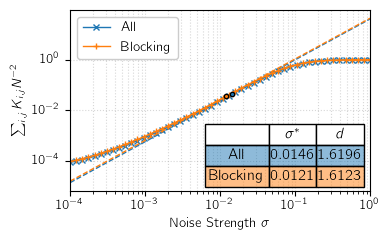

In [65]:
fig, ax = plot_loglog_slope_analysis(sigmas_loglog, sums_all, sums_block)
plt.savefig(
    f'../../CdVloglog_{subsample_step}_{sigma}.pdf', dpi=600, bbox_inches='tight')

## Get pointwise increase plot

In [66]:
t_escape_dict = {}
for sig in np.arange(0, sig_max + sig_step, sig_step):
    eps = (2 * dt_eff * sig**2)
    print(f"Processing epsilon = {eps:.6f}")

    L = make_L3d(det_traj, eps)
    Q = L[labels == blocking_idx][:,
                                  labels == blocking_idx].tocsr()
    t_escape = solve_escape_from_Q(Q)

    # Store
    t_escape_dict[eps] = t_escape

Processing epsilon = 0.000000
[iterative] GMRES converged with ILU preconditioner (n=4989, nnz=4320, density=0.0001736).
Processing epsilon = 0.000000
[iterative] GMRES converged with ILU preconditioner (n=4989, nnz=58705, density=0.002359).
Processing epsilon = 0.000001
[iterative] GMRES converged with ILU preconditioner (n=4989, nnz=141210, density=0.005673).
Processing epsilon = 0.000002
[iterative] GMRES converged with ILU preconditioner (n=4989, nnz=238715, density=0.009591).
Processing epsilon = 0.000003
[iterative] GMRES converged with ILU preconditioner (n=4989, nnz=346202, density=0.01391).
Processing epsilon = 0.000005
[iterative] GMRES converged with ILU preconditioner (n=4989, nnz=464791, density=0.01867).
Processing epsilon = 0.000007
[iterative] GMRES converged with ILU preconditioner (n=4989, nnz=590575, density=0.02373).
Processing epsilon = 0.000010
[iterative] GMRES converged with ILU preconditioner (n=4989, nnz=716895, density=0.0288).
Processing epsilon = 0.000013
[

In [67]:
with open(f"escape_times_dict_for_sample_points_{subsample_step}_{sigma}.pkl", "wb") as f:
    pickle.dump(t_escape_dict, f)

In [17]:
# with open("escape_times_dict_for_sample_points.pkl", "rb") as f:
#     t_escape_dict = pickle.load(f)
# with open("escape_times_dict_for_sample_points_finer.pkl", "rb") as f:
#     t_escape_dict = pickle.load(f)
with open(f"escape_times_dict_for_sample_points_{subsample_step}_{sigma}.pkl", "rb") as f:
    t_escape_dict = pickle.load(f)
t_escape_steps = t_escape_dict[0]
epsilons = np.array(sorted(t_escape_dict.keys(), key=float), dtype=float)
# stack arrays in that sorted order
rows = [np.asarray(t_escape_dict[p], dtype=float) for p in epsilons]
M = np.vstack(rows)
argmax_idx = np.argmax(M, axis=0)
best_value = M[argmax_idx, np.arange(M.shape[1])]
best_eps = epsilons[argmax_idx]
rel_increase = best_value / M[0, :]
# sample_points = np.where(
#     (rel_increase > 1.2253) & (np.abs(t_escape_steps - 14) < 1e-6)
# )[0]

<>:56: SyntaxWarning: invalid escape sequence '\s'
<>:56: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_23155/2963321803.py:56: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label('Maximizing noise strength $\sigma_{\mathrm{max}}$')


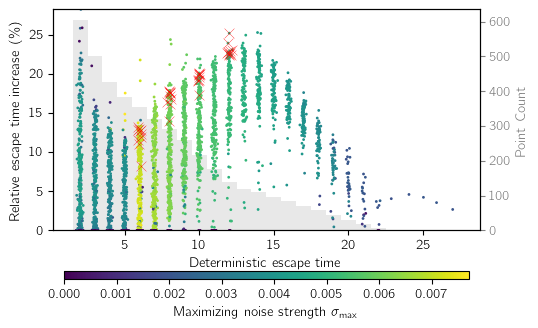

In [36]:
fig, ax = plt.subplots(figsize=(5.5, 3.5))

not_border_points = np.where(t_escape_steps > 10/subsample_step)[0]

# --- Histogram (background, secondary y-axis) ---
# Use integer bins so bars align with integer x-values
values, counts = np.unique(
    t_escape_steps[not_border_points], return_counts=True)

# Create twin axis for counts
ax_hist = ax.twinx()
ax_hist.bar(
    values, counts, width=1.,
    color='lightgray', alpha=0.5, align='center', zorder=0
)

# Put histogram behind scatter
ax.set_zorder(ax_hist.get_zorder() + 1)
ax.patch.set_visible(False)

# --- Jittered scatter ---
x_jitter_strength = 3e-3 * (np.max(t_escape_steps[not_border_points]) -
                            np.min(t_escape_steps[not_border_points]))
y_jitter_strength = 0 * (np.max(rel_increase[not_border_points]) -
                         np.min(rel_increase[not_border_points]))

x_jitter = np.random.normal(0, x_jitter_strength, size=len(t_escape_steps))
y_jitter = np.random.normal(0, y_jitter_strength, size=len(t_escape_steps))

sc = ax.scatter(
    t_escape_steps[not_border_points] + x_jitter[not_border_points],
    (rel_increase[not_border_points] + y_jitter[not_border_points] - 1) * 100,
    c=np.sqrt(best_eps[not_border_points] / (2*dt_eff)),
    cmap='viridis', s=1, alpha=1, zorder=2
)
sample_scatter = ax.scatter(
    t_escape_steps[sample_points_ext] + x_jitter[sample_points_ext],
    (rel_increase[sample_points_ext] + y_jitter[sample_points_ext] - 1) * 100,
    c="red", marker="x", s=50, alpha=1, zorder=3, linewidths=.25
)

# --- Formatting ---
ax.set_xlabel("Deterministic escape time")
ax.set_ylabel(r"Relative escape time increase (\%)")
ax_hist.set_ylabel("Point Count", color="gray")
ax_hist.tick_params(axis='y', colors='gray')

# Match y-axis to data range
y_min = np.min((rel_increase[not_border_points] - 1) * 100)
y_max = np.max((rel_increase[not_border_points] - 1) * 100)
ax.set_ylim(y_min, y_max)

# --- Colorbar at bottom ---
cbar = fig.colorbar(sc, ax=ax, orientation='horizontal',
                    fraction=0.03, aspect=50)  # pad=0.2)
cbar.set_label('Maximizing noise strength $\sigma_{\mathrm{max}}$')
# plt.savefig(f'../../TOLifetimes_increase_fine_{subsample_step}_{sigma}_no_crosses.pdf',
#             dpi=600, bbox_inches='tight')
plt.savefig(f'../../TOLifetimes_increase_fine_{subsample_step}_{sigma}.pdf',
            dpi=600, bbox_inches='tight')

# Look at entry points

/tmp/ipykernel_99781/2574433645.py:5: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(fixed[0, 4], fixed[0, 5], c='black', s=64, alpha=1,


Text(0, 0.5, 'X6')

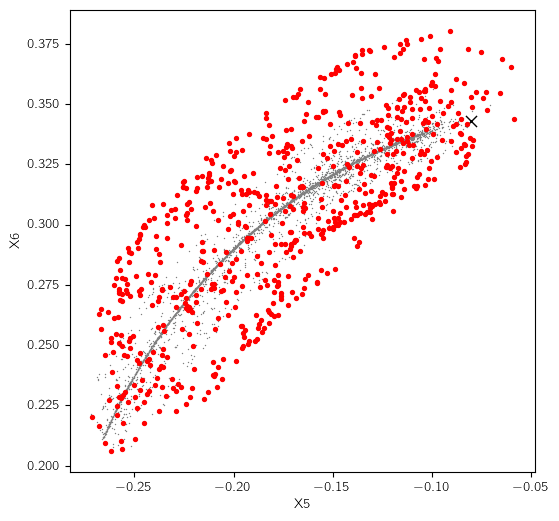

In [87]:
plt.figure(figsize=(6, 6))
sc = plt.scatter(det_traj[blocking_mask, 4], det_traj[blocking_mask, 5],
                 c="gray", s=1, linewidth=0,
                 rasterized=True)
plt.scatter(fixed[0, 4], fixed[0, 5], c='black', s=64, alpha=1,
            edgecolors='black', linewidths=1, marker="x")
plt.scatter(det_traj[entries, 4],
            det_traj[entries, 5],
            c='red', s=8, alpha=1,
            marker="o",
            label='Sample Points')

plt.xlabel("X5")
plt.ylabel("X6")

In [88]:
exits = np.where(
    (labels[:-1] == blocking_idx) & (labels[1:] != blocking_idx)
)[0] + 1
assert len(entries) == len(exits)

/tmp/ipykernel_99781/1682921653.py:12: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


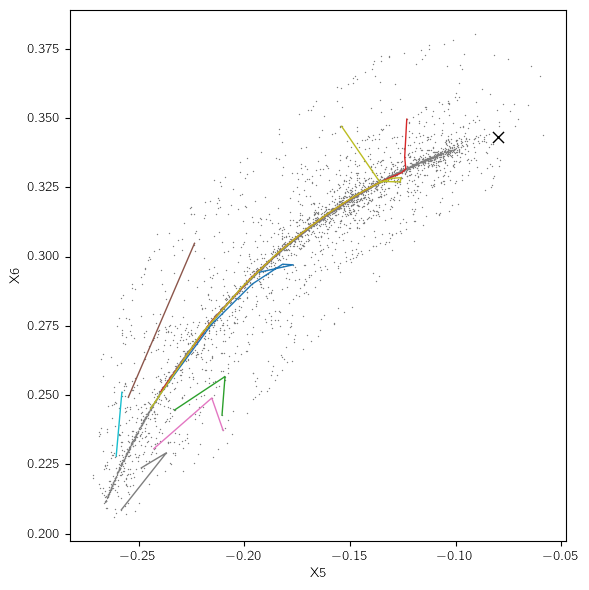

In [89]:
plt.figure(figsize=(6, 6))

# all blocking points (background)
plt.scatter(
    det_traj[blocking_mask, 4],
    det_traj[blocking_mask, 5],
    c="gray", s=1, linewidth=0,
    rasterized=True
)

# fixed point
plt.scatter(
    fixed[0, 4], fixed[0, 5],
    c='black', s=64,
    edgecolors='black',
    linewidths=1,
    marker="x"
)

for i in range(10):
    plt.plot(
        det_traj[entries[i]:exits[i], 4],
        det_traj[entries[i]:exits[i], 5],
        linewidth=1,
        zorder=3,
    )

plt.xlabel("X5")
plt.ylabel("X6")
plt.tight_layout()

/tmp/ipykernel_23155/4236052289.py:84: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axins.scatter(
/tmp/ipykernel_23155/4236052289.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


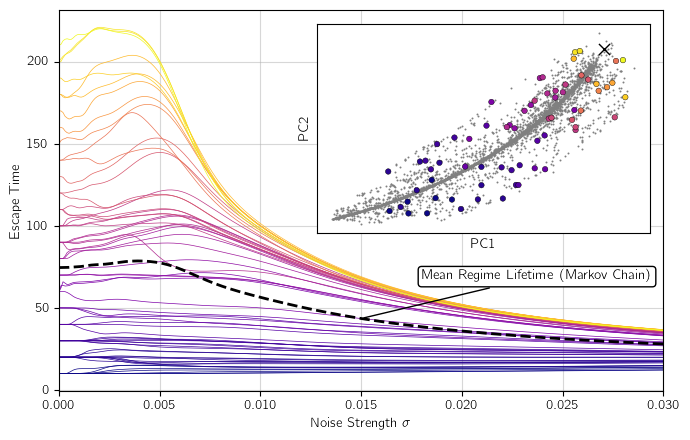

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

cmap = plt.get_cmap("plasma")

# --- full values (used for ordering only) ---
entry_escapes_full = M[0, indices_in_reduced]

# sort curves so high values are plotted last
order = np.argsort(entry_escapes_full)

# --- subsample AFTER sorting ---
subsample_n = 10
plot_idx = order[::subsample_n]

# --- recompute normalization ONLY on subset ---
entry_escapes_sub = entry_escapes_full[plot_idx]

norm = Normalize(
    vmin=entry_escapes_sub.min(),
    vmax=entry_escapes_sub.max()
)

colors_sub = cmap(norm(entry_escapes_sub))

# x-axis
ordered_eps = np.sqrt(epsilons / (2 * dt_eff))

# --- figure ---
fig, ax = plt.subplots(figsize=(7, 4.5))

# --- plot subsampled curves ---
for k, j in enumerate(plot_idx):
    ep = indices_in_reduced[j]
    ax.plot(
        ordered_eps,
        M[:, ep] * dt_eff,
        lw=0.5,
        color=colors_sub[k]
    )

# --- axes styling ---
ax.set_xlabel(r'Noise Strength $\sigma$')
ax.set_ylabel(r'Escape Time')
ax.grid(True, alpha=0.5)
ax.set_xlim(0, sig_max)

# --- inset ---
inset_size = 0.55
axins = inset_axes(
    ax,
    width=f"{int(inset_size*100)}%",
    height=f"{int(inset_size*100)}%",
    loc='upper right',
    borderpad=1.0
)

# background cloud
axins.scatter(
    PC_scores[blocking_mask, 0],
    PC_scores[blocking_mask, 1],
    c="gray",
    s=2,
    linewidth=0,
    rasterized=False,
    zorder=0,
    alpha=1
)

# subsampled colored points
axins.scatter(
    PC_scores[entries[plot_idx], 0],
    PC_scores[entries[plot_idx], 1],
    c=colors_sub,
    s=16,
    edgecolors='k',
    linewidths=0.3,
    zorder=5
)

# fixed point
axins.scatter(
    fixed_pcs[0, 0],
    fixed_pcs[0, 1],
    c='black',
    s=64,
    alpha=1,
    edgecolors='black',
    linewidths=1,
    marker="x"
)

axins.set_xlabel("PC1")
axins.set_ylabel("PC2")
axins.tick_params(
    axis='both', which='both',
    bottom=False, top=False,
    left=False, right=False,
    labelbottom=False, labelleft=False
)

# --- mean over ALL curves (not subsampled) ---
mean_curve = M[:, indices_in_reduced].mean(axis=1) * dt_eff

ax.plot(
    ordered_eps,
    mean_curve,
    lw=2.0,
    color="k",
    linestyle="--",
    label="Regime Lifetime (Markov Chain)"
)

# --- annotation ---
i_lab = len(ordered_eps) // 2
x_lab = ordered_eps[i_lab]
y_lab = mean_curve[i_lab]

ax.annotate(
    "Mean Regime Lifetime (Markov Chain)",
    xy=(x_lab, y_lab),
    xytext=(0.6, 0.3),
    textcoords='axes fraction',
    arrowprops=dict(arrowstyle='-', lw=1.0, color='k'),
    bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='k'),
    ha='left', va='center'
)

plt.tight_layout()
plt.savefig(
    f'../../CdV_lifetimes_fine_{subsample_step}_{sigma}.pdf', dpi=600, bbox_inches='tight')
plt.show()

# Ok now Monte Carlo empirically

In [99]:
import glob
import re
from scipy.spatial import cKDTree
tree = cKDTree(det_traj[:-1])

escape_results = {}  # plain dict
for fname in sorted(glob.glob("./cdv_model/data/dataOro20_sigma0p*.bin")):
    # extract sigma string from filename (e.g. "0p050")
    match = re.search(r"sigma([0-9p]+)\.bin", fname)
    sigma_str = match.group(1).replace(
        "p", ".")   # e.g. "0p050" -> "0.050"
    sigma_val = float(sigma_str)
    # if sigma_val < 0.009:
    #     continue
    if sigma_val > 0.03:
        break
    print(f"Processing sigma={sigma_val}")

    sig_data = load_d(fname, 6, int(2e6))[::subsample_step, :]

    # classify
    labels_new = classify_new_trajectory(
        det_traj[:-1], labels, sig_data, k=20, threshold=0.5
    )
    # labels_new = classify_new_trajectory_radius(
    #     det_traj[:-1], labels, sig_data, blocking_idx, 1e-1, tree=tree
    # )
    esc_dict = calculate_escape_times(labels_new, dt=dt_eff)

    # insert into dict safely
    for regime, times in esc_dict.items():
        if regime not in escape_results:
            escape_results[regime] = {}
        if sigma_val not in escape_results[regime]:
            escape_results[regime][sigma_val] = []
        escape_results[regime][sigma_val].extend(times)

Processing sigma=0.0
Processing sigma=0.0001
Processing sigma=0.0002
Processing sigma=0.0003
Processing sigma=0.0004
Processing sigma=0.0005
Processing sigma=0.0006
Processing sigma=0.0007
Processing sigma=0.0008
Processing sigma=0.0009
Processing sigma=0.001
Processing sigma=0.0011
Processing sigma=0.0012
Processing sigma=0.0013
Processing sigma=0.0014
Processing sigma=0.0015
Processing sigma=0.0016
Processing sigma=0.0017
Processing sigma=0.0018
Processing sigma=0.0019
Processing sigma=0.002
Processing sigma=0.0021
Processing sigma=0.0022
Processing sigma=0.0023
Processing sigma=0.0024
Processing sigma=0.0025
Processing sigma=0.0026
Processing sigma=0.0027
Processing sigma=0.0028
Processing sigma=0.0029
Processing sigma=0.003
Processing sigma=0.0031
Processing sigma=0.0032
Processing sigma=0.0033
Processing sigma=0.0034
Processing sigma=0.0035
Processing sigma=0.0036
Processing sigma=0.0037
Processing sigma=0.0038
Processing sigma=0.0039
Processing sigma=0.004
Processing sigma=0.0041

(<Figure size 500x300 with 1 Axes>,
 <Axes: xlabel='Sigma', ylabel='Regime Lifetime'>)

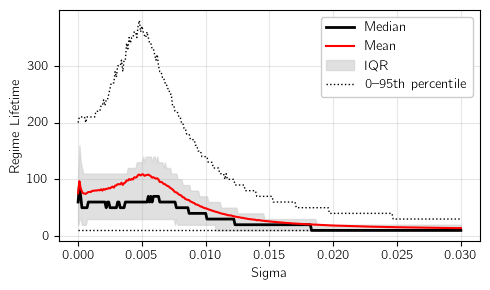

In [100]:
plot_lifetime_distributions_lines(

    escape_results, regime=blocking_idx, logx=False)

In [70]:
with open(f"escape_results_final__{subsample_step}_{sigma}.pkl", "wb") as f:
    pickle.dump(escape_results, f)

In [73]:
print("Markov, sigma=0: ", t_escape_dict[0][indices_in_reduced].mean())
print("Monte, sigma=0: ", np.array(escape_results[blocking_idx][0.]).mean())
print("Markov from Monte, sigma=0: ",
      M[:, indices_in_reduced].mean(axis=1)[0] * dt_eff)

Markov, sigma=0:  64.71232876712328
Monte, sigma=0:  64.55463347164591


NameError: name 'M' is not defined

In [37]:
with open(f"subsample_{subsample_step}_lifetimes_sigma_{sigma}.pkl", "rb") as f:
    escape_results, t_escape_dict = pickle.load(f)

In [40]:
blocking_idx = 1

<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_19645/4116203827.py:16: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel("Noise Strength $\sigma$")
/tmp/ipykernel_19645/4116203827.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


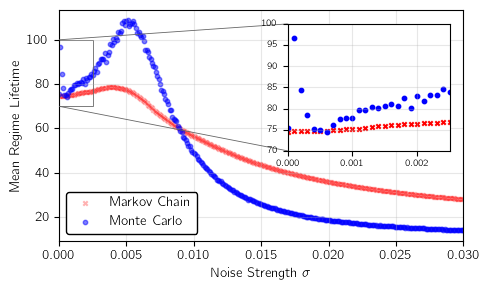

In [49]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(np.sqrt(np.array(sorted(t_escape_dict.keys())) / (dt_eff*2)),
           np.array([t_escape_dict[k][indices_in_reduced].mean() * dt_eff
                     for k in sorted(t_escape_dict.keys())]),
           label=f'Markov Chain', alpha=.3, s=10,  marker="x", color='red')
means = np.array([np.mean(v)
                  for k, v in sorted(escape_results[blocking_idx].items())])
ax.scatter(sorted(escape_results[blocking_idx].keys()), means,
           label=f'Monte Carlo', marker="o", color='blue', s=10, alpha=.5)
# means_fine = np.array([np.mean(v)
#                   for k, v in sorted(escape_results_fine[0].items())])
# ax.scatter(sorted(escape_results_fine[0].keys()), means_fine,
#            label=f'Monte Carlo fine', marker="s", color='darkgreen', s=10, alpha=.5)
ax.set_xlabel("Noise Strength $\sigma$")
ax.set_ylabel("Mean Regime Lifetime")
ax.grid(True, alpha=0.3)
ax.set_xlim(0, sig_max)

# --- inset axes (top right) ---
axins = inset_axes(
    ax,
    width="40%", height="55%",
    loc='upper right',
    borderpad=1.0
)

# replot same data in inset
axins.scatter(
    np.sqrt(np.array(sorted(t_escape_dict.keys())) / (dt_eff * 2)),
    np.array([t_escape_dict[k][indices_in_reduced].mean()*dt_eff
              for k in sorted(t_escape_dict.keys())]),
    alpha=1, s=10, marker="x", color='red'
)
axins.scatter(
    sorted(escape_results[blocking_idx].keys()),
    means,
    marker="o", color='blue', s=10, alpha=1
)

axins.set_xlim(0.0, 0.0025)
axins.set_ylim(70, 100)

axins.xaxis.set_major_locator(plt.MultipleLocator(0.001))
axins.yaxis.set_major_locator(plt.MultipleLocator(5))
mark_inset(ax, axins, loc1=2, loc2=3, fc="none", ec="0.4", lw=0.6)

axins.tick_params(labelsize=7)
axins.grid(True, alpha=0.3)

# --- legend: lower right, below inset ---
ax.legend(
    loc='lower right',
    bbox_to_anchor=(0.98, 0.1),
    frameon=True,
    framealpha=1.0,
    facecolor='white',
    edgecolor='black'
)

ax.legend(facecolor='white', edgecolor='black', loc='lower left', framealpha=1)
plt.tight_layout()
plt.savefig(f"../../CdV_MeanRegimeLifetimeComparison_{subsample_step}_{sigma}.pdf",
            dpi=600, bbox_inches="tight")

In [90]:
with open(f"subsample_{subsample_step}_lifetimes_sigma_{sigma}.pkl", "rb") as f:
    escape_results, t_escape_dict = pickle.load(f)
blocking_idx = 0

<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_19645/2249148711.py:22: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel("Noise Strength $\sigma$")
/tmp/ipykernel_19645/2249148711.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


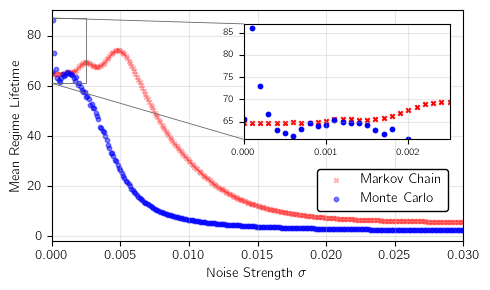

In [94]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
fig, ax = plt.subplots(figsize=(5, 3))

# --- main scatter plots ---
ax.scatter(
    np.sqrt(np.array(sorted(t_escape_dict.keys())) / (dt_eff * 2)),
    np.array([t_escape_dict[k][indices_in_reduced].mean()
              for k in sorted(t_escape_dict.keys())]),
    label='Markov Chain',
    alpha=0.3, s=10, marker="x", color='red'
)

means = np.array([np.mean(v)
                  for k, v in sorted(escape_results[blocking_idx].items())])
ax.scatter(
    sorted(escape_results[blocking_idx].keys()),
    means,
    label='Monte Carlo',
    marker="o", color='blue', s=10, alpha=0.5
)

ax.set_xlabel("Noise Strength $\sigma$")
ax.set_ylabel("Mean Regime Lifetime")
ax.grid(True, alpha=0.3)
ax.set_xlim(0, sig_max)

# --- inset axes (top right) ---
axins = inset_axes(
    ax,
    width="50%", height="50%",
    loc='upper right',
    borderpad=1.0
)

# replot same data in inset
axins.scatter(
    np.sqrt(np.array(sorted(t_escape_dict.keys())) / (dt_eff * 2)),
    np.array([t_escape_dict[k][indices_in_reduced].mean()
              for k in sorted(t_escape_dict.keys())]),
    alpha=1, s=10, marker="x", color='red'
)
axins.scatter(
    sorted(escape_results[blocking_idx].keys()),
    means,
    marker="o", color='blue', s=10, alpha=1
)

axins.set_xlim(0.0, 0.0025)
axins.set_ylim(61, 87)

axins.xaxis.set_major_locator(plt.MultipleLocator(0.001))
axins.yaxis.set_major_locator(plt.MultipleLocator(5))
mark_inset(ax, axins, loc1=2, loc2=3, fc="none", ec="0.4", lw=0.6)

axins.tick_params(labelsize=7)
axins.grid(True, alpha=0.3)

# --- legend: lower right, below inset ---
ax.legend(
    loc='lower right',
    bbox_to_anchor=(0.98, 0.1),
    frameon=True,
    framealpha=1.0,
    facecolor='white',
    edgecolor='black'
)

plt.tight_layout()
plt.savefig("../../CdV_MeanRegimeLifetimeComparison.pdf",
            dpi=600, bbox_inches="tight")

## Derive points
- We want the points far from exit and entrance
- so those where rel increase > 25 & det esc steps > 150

In [22]:
# sample_points = np.where(
#     (rel_increase > 1.25) & (np.abs(t_escape_steps - 140) < 1e-6)
# )[0]
# offsets = np.array([0, 20, 40, 60])
# sample_points_ext = (sample_points[:, None] + offsets).ravel()
sample_points = np.where(
    (rel_increase > 1.223) & (np.abs(t_escape_steps - 12) < 1e-6)
)[0]
offsets = np.array([0, 2, 4, 6])
sample_points_ext = (sample_points[:, None] + offsets).ravel()

/tmp/ipykernel_99781/2635669882.py:5: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(fixed[0, 4], fixed[0, 5], c='black', s=64, alpha=1,


Text(0, 0.5, 'X6')

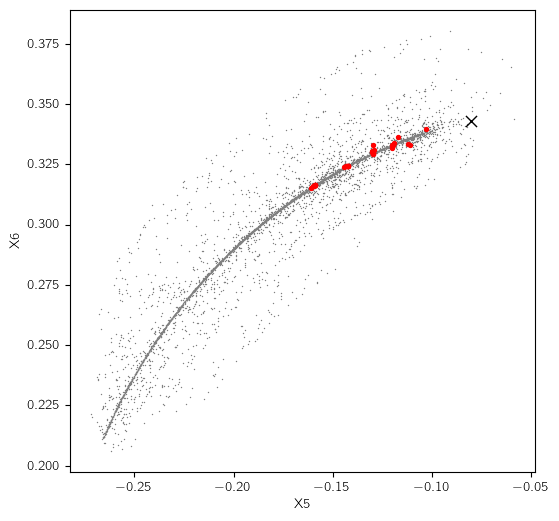

In [149]:
plt.figure(figsize=(6, 6))
sc = plt.scatter(det_traj[blocking_mask, 4], det_traj[blocking_mask, 5],
                 c="gray", s=1, linewidth=0,
                 rasterized=True)
plt.scatter(fixed[0, 4], fixed[0, 5], c='black', s=64, alpha=1,
            edgecolors='black', linewidths=1, marker="x")
plt.scatter(x_inits[:, 4],
            x_inits[:, 5],
            c='red', s=8, alpha=1,
            marker="o",
            label='Sample Points')

plt.xlabel("X5")
plt.ylabel("X6")

In [150]:
import pickle
with open(f"sample_points_{subsample_step}_{sigma}.pkl", "wb") as f:
    pickle.dump(sample_points, f)

## Monte Carlo Escape times

In [152]:
@nb.njit(parallel=True, fastmath=True)
def _integrate_cdv_kernel(
    dt_true,
    n_steps,
    sigmas,
    x0,
    noise,
    out,
    store_every
):
    n_sigma = sigmas.shape[0]

    # parameters
    x1star = 0.95
    x4star = -0.76095
    C = 0.1
    beta = 1.25
    gamma = 0.2
    b = 0.5
    epsilon = 1.44050610585137

    sqrt2 = math.sqrt(2.0)
    pi = math.pi

    # precomputed constants
    alpha1 = (8*sqrt2/pi)*(1/3)*((b*b)/(b*b+1))
    alpha2 = (8*sqrt2/pi)*(4/15)*((b*b+3)/(b*b+4))

    beta1 = beta*b*b/(b*b+1)
    beta2 = beta*b*b/(b*b+4)

    gamma1 = gamma*(4/3)*(sqrt2*b/(pi*(b*b+1)))
    gamma2 = gamma*(32/15)*(sqrt2*b/(pi*(b*b+4)))

    gamma_tld1 = gamma*(4/3)*(sqrt2*b/pi)
    gamma_tld2 = gamma*(8/15)*(sqrt2*b/pi)

    delta1 = (64*sqrt2/(15*pi))*((b*b)/(b*b+1))
    delta2 = (64*sqrt2/(15*pi))*((b*b-3)/(b*b+4))

    # state arrays
    x = np.zeros((n_sigma, 6))
    k1 = np.zeros((n_sigma, 6))
    k2 = np.zeros((n_sigma, 6))

    for i in range(n_sigma):
        for j in range(6):
            x[i, j] = x0[j]

    store_idx = 0

    for step in range(n_steps):

        # k1
        for i in nb.prange(n_sigma):
            x1, x2, x3, x4, x5, x6 = x[i]

            k1[i, 0] = dt_true*(gamma_tld1*x3 - C*(x1-x1star))
            k1[i, 3] = dt_true*(gamma_tld2*x6 - C*(x4-x4star)
                                + epsilon*(x2*x6 - x3*x5))

            k1[i, 1] = dt_true*(-(alpha1*x1 - beta1)*x3 - C*x2
                                - delta1*x4*x6)
            k1[i, 4] = dt_true*(-(alpha2*x1 - beta2)*x6 - C*x5
                                - delta2*x4*x3)

            k1[i, 2] = dt_true*((alpha1*x1 - beta1)*x2 - gamma1*x1
                                - C*x3 + delta1*x4*x5)
            k1[i, 5] = dt_true*((alpha2*x1 - beta2)*x5 - gamma2*x4
                                - C*x6 + delta2*x4*x2)

        # k2
        for i in nb.prange(n_sigma):
            x1 = x[i, 0] + 0.5*k1[i, 0]
            x2 = x[i, 1] + 0.5*k1[i, 1]
            x3 = x[i, 2] + 0.5*k1[i, 2]
            x4 = x[i, 3] + 0.5*k1[i, 3]
            x5 = x[i, 4] + 0.5*k1[i, 4]
            x6 = x[i, 5] + 0.5*k1[i, 5]

            k2[i, 0] = dt_true*(gamma_tld1*x3 - C*(x1-x1star))
            k2[i, 3] = dt_true*(gamma_tld2*x6 - C*(x4-x4star)
                                + epsilon*(x2*x6 - x3*x5))

            k2[i, 1] = dt_true*(-(alpha1*x1 - beta1)*x3 - C*x2
                                - delta1*x4*x6)
            k2[i, 4] = dt_true*(-(alpha2*x1 - beta2)*x6 - C*x5
                                - delta2*x4*x3)

            k2[i, 2] = dt_true*((alpha1*x1 - beta1)*x2 - gamma1*x1
                                - C*x3 + delta1*x4*x5)
            k2[i, 5] = dt_true*((alpha2*x1 - beta2)*x5 - gamma2*x4
                                - C*x6 + delta2*x4*x2)

        # update with noise
        for i in nb.prange(n_sigma):
            s = sigmas[i]
            for j in range(6):
                x[i, j] += k2[i, j] + s * noise[step, i, j]

        # store
        if step % store_every == 0:
            for i in nb.prange(n_sigma):
                for j in range(6):
                    out[store_idx, i, j] = x[i, j]
            store_idx += 1


def integrate_cdv_noisy(
    dt_out,
    T,
    sigmas,
    x0,
    dt_true=2e-4,
    seed=None
):
    """
    Parameters
    ----------
    dt_out : float
        Desired sampling timestep of the returned trajectory.
    T : float
        Total integration time.
    sigmas : array-like, shape (n_sigma,)
        Noise strengths.
    x0 : array-like, shape (6,)
        Initial condition.
    dt_true : float, optional
        Internal integration timestep (default 1e-4).
    seed : int or None
        RNG seed.

    Returns
    -------
    out : ndarray, shape (n_out, n_sigma, 6)
        Sampled trajectories.
    """

    sigmas = np.asarray(sigmas, dtype=np.float64)
    x0 = np.asarray(x0, dtype=np.float64)

    if dt_out < dt_true:
        raise ValueError("dt_out must be >= dt_true")

    store_every = int(round(dt_out / dt_true))
    if not np.isclose(store_every * dt_true, dt_out):
        raise ValueError("dt_out must be an integer multiple of dt_true")

    n_steps = int(round(T / dt_true))
    n_out = n_steps // store_every

    rng = np.random.default_rng(seed)
    noise = rng.standard_normal((n_steps, sigmas.size, 6)) * np.sqrt(dt_true)

    out = np.empty((n_out, sigmas.size, 6), dtype=np.float64)

    _integrate_cdv_kernel(
        dt_true,
        n_steps,
        sigmas,
        x0,
        noise,
        out,
        store_every
    )

    return out

In [41]:
from scipy.spatial import cKDTree
x_inits = det_traj[blocking_mask][sample_points_ext]
T_max = 500
sigmas = np.arange(0, sig_max + sig_step, sig_step)
tree = cKDTree(det_traj[:-1])
point_esc = np.empty((len(x_inits), len(sigmas)), dtype=np.float64)
n_mc = 100

In [155]:

for i_p, p in enumerate(x_inits):
    print(f"Processing point {i_p+1}/{len(x_inits)}")
    esc_mc = np.empty((n_mc, len(sigmas)), dtype=np.int32)

    for i_mc in range(n_mc):
        print(f"  MC run {i_mc+1}/{n_mc}")
        mc_traj = integrate_cdv_noisy(
            dt_out=dt_eff,
            T=T_max,
            sigmas=sigmas,
            x0=p,
            dt_true=2e-3
        )
        for i_s, s in enumerate(sigmas):
            labels_new = classify_new_trajectory_radius(
                det_traj[:-1], labels, mc_traj[:, i_s, :], blocking_idx, 1e-1, tree=tree
            )
            mask = (labels_new == blocking_idx)
            esc_mc[i_mc, i_s] = (
                np.argmax(~mask) if not mask.all() else mask.size
            )

    # Monte Carlo average
    point_esc[i_p, :] = esc_mc.mean(axis=0)

Processing point 1/40
  MC run 1/100
  MC run 2/100
  MC run 3/100
  MC run 4/100
  MC run 5/100
  MC run 6/100
  MC run 7/100
  MC run 8/100
  MC run 9/100
  MC run 10/100
  MC run 11/100
  MC run 12/100
  MC run 13/100
  MC run 14/100
  MC run 15/100
  MC run 16/100
  MC run 17/100
  MC run 18/100
  MC run 19/100
  MC run 20/100
  MC run 21/100
  MC run 22/100
  MC run 23/100
  MC run 24/100
  MC run 25/100
  MC run 26/100
  MC run 27/100
  MC run 28/100
  MC run 29/100
  MC run 30/100
  MC run 31/100
  MC run 32/100
  MC run 33/100
  MC run 34/100
  MC run 35/100
  MC run 36/100
  MC run 37/100
  MC run 38/100
  MC run 39/100
  MC run 40/100
  MC run 41/100
  MC run 42/100
  MC run 43/100
  MC run 44/100
  MC run 45/100
  MC run 46/100
  MC run 47/100
  MC run 48/100
  MC run 49/100
  MC run 50/100
  MC run 51/100
  MC run 52/100
  MC run 53/100
  MC run 54/100
  MC run 55/100
  MC run 56/100
  MC run 57/100
  MC run 58/100
  MC run 59/100
  MC run 60/100
  MC run 61/100
  MC run 62

In [156]:
with open(f"point_escapes_MonteCarlo_{subsample_step}_{sigma}.pkl", "wb") as f:
    pickle.dump(point_esc, f)

In [160]:
groups = [sample_points + off for off in offsets]

<>:67: SyntaxWarning: invalid escape sequence '\s'
<>:67: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_23155/3750544453.py:67: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel("Noise Strength $\sigma$")
/tmp/ipykernel_23155/3750544453.py:31: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axins.scatter(fixed_pcs[0, 0], fixed_pcs[0, 1], c='black', s=64, alpha=1,
/tmp/ipykernel_23155/3750544453.py:62: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axins.scatter(PC_scores[blocking_mask][s_p, 0],
/tmp/ipykernel_23155/3750544453.py:79: UserWa

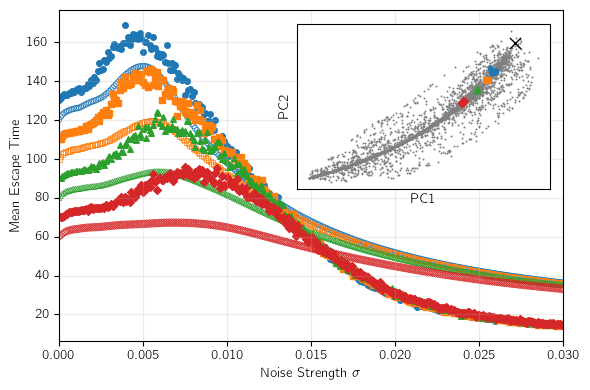

In [47]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

with open(f"point_escapes_MonteCarlo_{subsample_step}_{sigma}.pkl", "rb") as f:
    point_esc = pickle.load(f)


xs_point = sigmas
xs_M = np.sqrt(epsilons / (2 * dt_eff))
offsets = np.array([0, 20, 40, 60])/subsample_step

# local (point_esc / x_inits) indices: stride-based grouping
local_groups = [np.arange(i, 32, 4) for i in range(4)]

# global (M) indices remain offset-based
global_groups = [(sample_points + off).astype(int) for off in offsets]
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(6)]
markers = ['o', 's', '^', 'D', 'v', 'P']
filled_size = 28
hollow_size = 50

x_point = sigmas
x_M = np.sqrt(epsilons / (2 * dt_eff))

fig, ax = plt.subplots(figsize=(6, 4))
inset_size = 0.5  # fraction of parent axes (you can tweak)
axins = inset_axes(ax, width=f"{int(inset_size*100)}%", height=f"{int(inset_size*100)}%",
                   loc='upper right', borderpad=1.0)
axins.scatter(PC_scores[blocking_mask, 0], PC_scores[blocking_mask, 1],
              c="gray", s=2, linewidth=0, rasterized=False, zorder=0, alpha=1)
axins.scatter(fixed_pcs[0, 0], fixed_pcs[0, 1], c='black', s=64, alpha=1,
              edgecolors='black', linewidths=1, marker="x")
for i in range(4):
    # ---- point_esc: already reduced to 32 points ----
    y_point = point_esc[local_groups[i], :].mean(axis=0) * dt_eff
    # y_M = M[:, global_groups[i]].mean(axis=1) * dt_eff
    # y_point = y_point - (y_point[0] - y_M[0])

    s_p = sample_points_ext[local_groups[i]]
    marker = markers[i]
    ax.scatter(
        x_point, y_point,
        s=16,
        linewidths=1,
        alpha=1,
        marker=marker,
        facecolors=colors[i],
        edgecolors=colors[i]
    )

    # ---- M: full trajectory, index with global indices ----
    y_M = M[:, global_groups[i]].mean(axis=1) * dt_eff

    ax.scatter(
        x_M, y_M,
        s=16,
        marker=marker,
        facecolors='none',
        edgecolors=colors[i],
        linewidths=.5
    )
    axins.scatter(PC_scores[blocking_mask][s_p, 0],
                  PC_scores[blocking_mask][s_p, 1],
                  c=colors[i], s=24, edgecolors='None', linewidths=0.3,
                  marker=marker, zorder=5)

ax.set_xlabel("Noise Strength $\sigma$")
ax.set_ylabel("Mean Escape Time")
# ax.legend(ncol=2)
ax.grid(True, alpha=0.25)
ax.set_xlim(0, sigmas[-1])

axins.set_xlabel("PC1")
axins.set_ylabel("PC2")
axins.tick_params(axis='both', which='both',
                  bottom=False, top=False, left=False, right=False,
                  labelbottom=False, labelleft=False)

plt.tight_layout()
plt.savefig(f'../../CdV_point_vs_MeanEscape_{subsample_step}_{sigma}.pdf',
            dpi=600, bbox_inches='tight')